In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage,fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

In [12]:
X,_ = make_blobs(n_samples = 10,centers = 3,cluster_std = 1.0,random_state = 42)

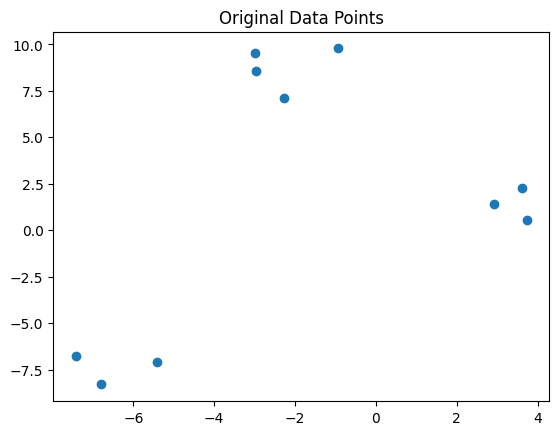

In [13]:
plt.scatter(X[:,0],X[:,1])
plt.title("Original Data Points")
plt.show()

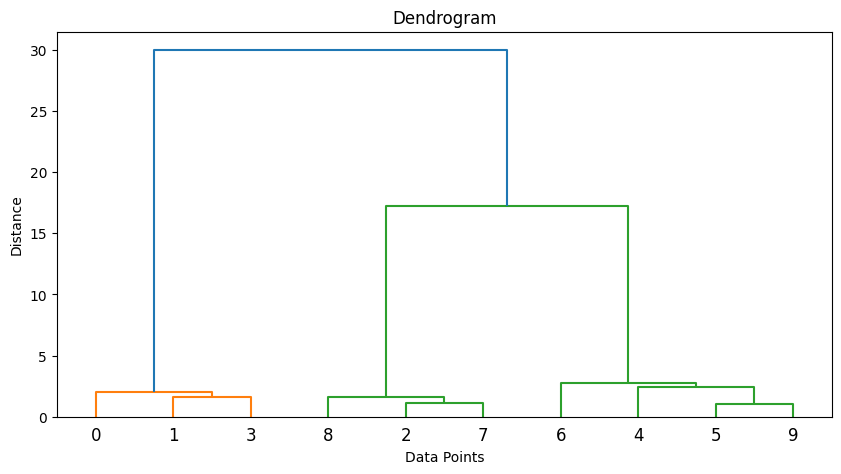

In [14]:
# Perform hierarchical clustering using Ward's linkage
Z = linkage(X, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

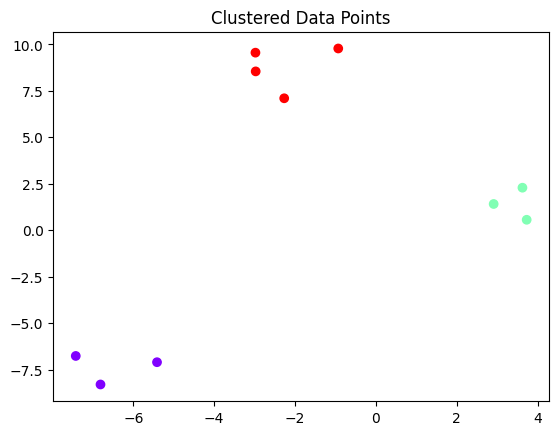

In [16]:
# Cut the dendrogram to form 3 clusters
clusters = fcluster(Z, t=3, criterion='maxclust')

# Plot the clustered data
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='rainbow')
plt.title("Clustered Data Points")
plt.show()


---

### **What is Hierarchical Clustering?**

Hierarchical clustering builds a hierarchy of clusters by either:
1. **Agglomerative Approach (Bottom-Up):** Starts with each data point as its own cluster and merges them into larger clusters iteratively.
2. **Divisive Approach (Top-Down):** Starts with all data points in one cluster and splits them into smaller clusters iteratively.

The most commonly used method is **agglomerative hierarchical clustering**, so we'll focus on that.

---

### **How Does Agglomerative Hierarchical Clustering Work?**

1. **Step 1: Treat Each Data Point as a Cluster**
   - Initially, every data point is treated as an individual cluster.

2. **Step 2: Compute Pairwise Distances**
   - Calculate the distance between every pair of clusters using a distance metric (e.g., Euclidean distance).

3. **Step 3: Merge Closest Clusters**
   - Combine the two closest clusters into a single cluster based on a linkage criterion (explained below).

4. **Step 4: Repeat**
   - Recompute distances between the new cluster and existing clusters.
   - Continue merging until all data points belong to a single cluster or a desired number of clusters is reached.

5. **Step 5: Visualize Using a Dendrogram**
   - A dendrogram is a tree-like diagram that shows the merging process and helps decide the number of clusters.

---

### **Linkage Criteria**
The way distances between clusters are calculated determines how the clusters are merged. Common linkage methods include:

1. **Single Linkage:** Uses the shortest distance between any two points in the two clusters.
2. **Complete Linkage:** Uses the longest distance between any two points in the two clusters.
3. **Average Linkage:** Uses the average distance between all pairs of points in the two clusters.
4. **Ward’s Method:** Minimizes the total within-cluster variance after merging.

---

### **Example: Agglomerative Hierarchical Clustering on a Dataset**

Let’s use Python and the `scipy` library to perform hierarchical clustering on a simple dataset.

#### **Dataset**
We’ll create a small synthetic dataset for demonstration purposes.

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import make_blobs

# Generate synthetic data
X, _ = make_blobs(n_samples=10, centers=3, cluster_std=1.0, random_state=42)

# Plot the data points
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Data Points")
plt.show()
```

#### **Perform Hierarchical Clustering**

```python
# Perform hierarchical clustering using Ward's linkage
Z = linkage(X, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()
```

#### **Interpret the Dendrogram**
- The vertical lines represent clusters.
- The height of each merge indicates the distance between the clusters being merged.
- To decide the number of clusters, look for the largest vertical gap (where cutting the dendrogram makes sense).

#### **Assign Clusters**
We can assign clusters by cutting the dendrogram at a specific height.

```python
# Cut the dendrogram to form 3 clusters
clusters = fcluster(Z, t=3, criterion='maxclust')

# Plot the clustered data
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='rainbow')
plt.title("Clustered Data Points")
plt.show()
```

---

### **Other Types of Clustering Algorithms**

Here’s a quick overview of other popular clustering techniques:

#### **1. K-Means Clustering**
- Divides data into `k` clusters by minimizing the variance within each cluster.
- Requires specifying the number of clusters (`k`) beforehand.
- Pros:
  - Simple and fast for large datasets.
  - Works well with spherical clusters.
- Cons:
  - Sensitive to initial centroid placement.
  - Struggles with non-spherical clusters.

#### **2. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**
- Groups together points that are closely packed, marking outliers as noise.
- Does not require specifying the number of clusters.
- Pros:
  - Handles noise and outliers well.
  - Finds arbitrarily shaped clusters.
- Cons:
  - Struggles with varying densities.
  - Requires tuning parameters like `eps` and `min_samples`.

#### **3. Gaussian Mixture Models (GMM)**
- Assumes data points are generated from a mixture of several Gaussian distributions.
- Provides probabilistic cluster assignments.
- Pros:
  - Flexible and works well with overlapping clusters.
  - Provides soft clustering (probability of belonging to each cluster).
- Cons:
  - Computationally expensive for large datasets.
  - Assumes data follows a Gaussian distribution.

#### **4. Spectral Clustering**
- Uses graph theory to cluster data based on similarity matrices.
- Good for complex, non-linearly separable data.
- Pros:
  - Effective for non-convex clusters.
- Cons:
  - Computationally intensive.
  - Requires careful selection of the similarity matrix.

---

### **Pros and Cons of Hierarchical Clustering**

#### **Pros:**
1. **No Need to Specify the Number of Clusters:** You can decide the number of clusters by analyzing the dendrogram.
2. **Produces a Dendrogram:** Helps visualize the clustering process and relationships between clusters.
3. **Flexible Linkage Criteria:** Allows customization of how clusters are merged.

#### **Cons:**
1. **Computationally Expensive:** Time complexity is O(n³), making it slow for large datasets.
2. **Not Suitable for Large Datasets:** Memory requirements can be prohibitive.
3. **Sensitive to Noise and Outliers:** Single linkage is especially sensitive to outliers.

---

### **When to Use Hierarchical Clustering?**
- When you don’t know the number of clusters beforehand.
- When you need a visual representation of the clustering process (via dendrograms).
- For small to medium-sized datasets where computational cost is manageable.

---

### **Conclusion**
Hierarchical clustering is a versatile and intuitive clustering technique that provides insights into the structure of your data. However, it has limitations, especially for large datasets. Depending on your problem, you might choose other clustering methods like K-means, DBSCAN, or GMM.



Hierarchical clustering is a powerful unsupervised machine learning technique used to group similar data points into clusters. It builds a hierarchy of clusters, either by merging smaller clusters into larger ones (**agglomerative**) or splitting larger clusters into smaller ones (**divisive**). Below, I’ll explain the **core ideas**, **types**, **distance measures**, and **parameters** in detail.

---

### **Core Ideas of Hierarchical Clustering**

1. **Hierarchy Formation:**
   - Hierarchical clustering creates a tree-like structure (called a **dendrogram**) that represents how clusters are merged (or split).
   - Each level of the dendrogram corresponds to a different granularity of clustering.

2. **No Predefined Number of Clusters:**
   - Unlike algorithms like K-means, hierarchical clustering doesn’t require you to specify the number of clusters beforehand. You can decide the number of clusters by analyzing the dendrogram.

3. **Linkage Criteria:**
   - The method used to calculate the distance between clusters determines how clusters are merged. This is called the **linkage criterion**.

4. **Distance Metric:**
   - A distance metric (e.g., Euclidean, Manhattan) is used to measure the similarity between data points or clusters.

5. **Two Main Approaches:**
   - **Agglomerative (Bottom-Up):** Starts with each data point as its own cluster and iteratively merges the closest clusters.
   - **Divisive (Top-Down):** Starts with all data points in one cluster and recursively splits them into smaller clusters.

---

### **Types of Hierarchical Clustering**

#### 1. **Agglomerative Hierarchical Clustering**
   - **Process:**
     1. Start with each data point as its own cluster.
     2. Compute pairwise distances between clusters using a linkage criterion.
     3. Merge the two closest clusters into a single cluster.
     4. Repeat until all data points belong to one cluster or a desired number of clusters is reached.
   - **Advantages:**
     - Intuitive and widely used.
     - Works well for small to medium-sized datasets.
   - **Disadvantages:**
     - Computationally expensive for large datasets (O(n³) complexity).

#### 2. **Divisive Hierarchical Clustering**
   - **Process:**
     1. Start with all data points in one cluster.
     2. Split the cluster into two sub-clusters based on some criterion (e.g., maximizing inter-cluster distance).
     3. Recursively split sub-clusters until each data point is its own cluster or a stopping condition is met.
   - **Advantages:**
     - Provides finer control over splitting criteria.
   - **Disadvantages:**
     - More complex to implement than agglomerative clustering.
     - Even more computationally expensive.

---

### **How Distance is Measured**

To determine which clusters should be merged (or split), hierarchical clustering relies on **distance metrics** and **linkage criteria**.

#### **Distance Metrics**
A distance metric measures the similarity or dissimilarity between two data points. Common distance metrics include:

1. **Euclidean Distance:**
   $$
   d(x, y) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}
   $$
   - Measures straight-line distance between two points.
   - Most commonly used.

2. **Manhattan Distance:**
   $$
   d(x, y) = \sum_{i=1}^n |x_i - y_i|
   $$
   - Measures the sum of absolute differences along each dimension.

3. **Cosine Similarity:**
   $$
   \text{similarity}(x, y) = \frac{x \cdot y}{\|x\| \|y\|}
   $$
   - Measures the cosine of the angle between two vectors.
   - Often used for text or high-dimensional data.

4. **Minkowski Distance:**
   $$
   d(x, y) = \left(\sum_{i=1}^n |x_i - y_i|^p\right)^{1/p}
   $$
   - Generalization of Euclidean and Manhattan distances (p=2 for Euclidean, p=1 for Manhattan).

---

#### **Linkage Criteria**
The linkage criterion determines how the distance between two clusters is calculated. Common linkage methods include:

1. **Single Linkage:**
   - Uses the shortest distance between any two points in the two clusters.
   - Formula:
     $$
     d(C_1, C_2) = \min_{x \in C_1, y \in C_2} d(x, y)
     $$
   - **Pros:** Captures elongated clusters.
   - **Cons:** Sensitive to noise and outliers.

2. **Complete Linkage:**
   - Uses the longest distance between any two points in the two clusters.
   - Formula:
     $$
     d(C_1, C_2) = \max_{x \in C_1, y \in C_2} d(x, y)
     $$
   - **Pros:** Produces more compact clusters.
   - **Cons:** Can break up natural clusters.

3. **Average Linkage:**
   - Uses the average distance between all pairs of points in the two clusters.
   - Formula:
     $$
     d(C_1, C_2) = \frac{1}{|C_1||C_2|} \sum_{x \in C_1} \sum_{y \in C_2} d(x, y)
     $$
   - **Pros:** Balances sensitivity to outliers and compactness.
   - **Cons:** Computationally more expensive.

4. **Ward’s Method:**
   - Minimizes the increase in total within-cluster variance after merging.
   - Formula:
     $$
     d(C_1, C_2) = \text{Increase in Sum of Squares}
     $$
   - **Pros:** Produces spherical clusters.
   - **Cons:** Sensitive to outliers.

---

### **Key Parameters in Hierarchical Clustering**

1. **Distance Metric:**
   - Determines how distances between data points are calculated (e.g., Euclidean, Manhattan, Cosine).

2. **Linkage Criterion:**
   - Determines how distances between clusters are calculated (e.g., Single, Complete, Average, Ward).

3. **Number of Clusters:**
   - While hierarchical clustering doesn’t require specifying the number of clusters upfront, you can decide it later by cutting the dendrogram at a specific height.

4. **Threshold (for Cutting Dendrogram):**
   - If you want to automatically determine the number of clusters, you can set a threshold distance for cutting the dendrogram.

---

### **Steps to Perform Hierarchical Clustering**

1. **Choose a Distance Metric:**
   - Decide how to measure the similarity between data points.

2. **Compute Pairwise Distances:**
   - Calculate the distance matrix for all data points.

3. **Choose a Linkage Criterion:**
   - Decide how to merge clusters (e.g., Single, Complete, Average, Ward).

4. **Build the Dendrogram:**
   - Iteratively merge clusters and record the process in a dendrogram.

5. **Cut the Dendrogram:**
   - Decide the number of clusters by cutting the dendrogram at a specific height or based on a threshold.

6. **Assign Cluster Labels:**
   - Assign each data point to a cluster based on the dendrogram cut.

---

### **Applications of Hierarchical Clustering**

1. **Biology:**
   - Used in phylogenetic analysis to group organisms based on genetic similarity.

2. **Customer Segmentation:**
   - Groups customers based on purchasing behavior or demographic data.

3. **Image Segmentation:**
   - Groups pixels in an image based on color or texture similarity.

4. **Document Clustering:**
   - Groups documents based on their content or topic similarity.

---

### **Summary Table: Pros and Cons**

| **Method**          | **Pros**                                                                 | **Cons**                                                                 |
|----------------------|--------------------------------------------------------------------------|--------------------------------------------------------------------------|
| **Agglomerative**    | Intuitive, no need to specify `k`, produces dendrograms                 | Computationally expensive, sensitive to noise                           |
| **Divisive**         | Fine-grained control over splitting, works well for certain datasets    | Complex to implement, even more computationally expensive               |
| **Single Linkage**   | Captures elongated clusters                                             | Sensitive to noise and outliers                                         |
| **Complete Linkage** | Produces compact clusters                                               | Can break up natural clusters                                           |
| **Average Linkage**  | Balances sensitivity to outliers and compactness                        | More computationally expensive                                          |
| **Ward’s Method**    | Produces spherical clusters, minimizes variance                         | Sensitive to outliers                                                   |

---

### **Final Thoughts**
Hierarchical clustering is a versatile and interpretable clustering technique, especially useful when you want to understand the relationships between clusters. However, its computational cost makes it less suitable for very large datasets. By carefully choosing the distance metric, linkage criterion, and dendrogram-cutting strategy, you can tailor hierarchical clustering to your specific problem.



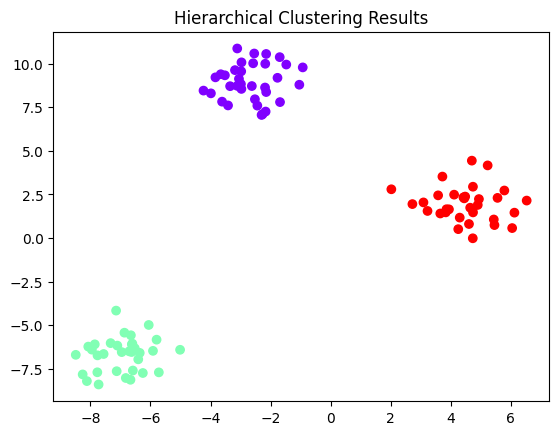

In [18]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic data
X, _ = make_blobs(n_samples=100, centers=3, cluster_std=1.0, random_state=42)

# Perform hierarchical clustering
model = AgglomerativeClustering(
    n_clusters=3,           # Number of clusters
    metric="euclidean",   # Distance metric
    linkage="ward"          # Linkage criterion
)

# Fit the model and predict clusters
clusters = model.fit_predict(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='rainbow')
plt.title("Hierarchical Clustering Results")
plt.show()

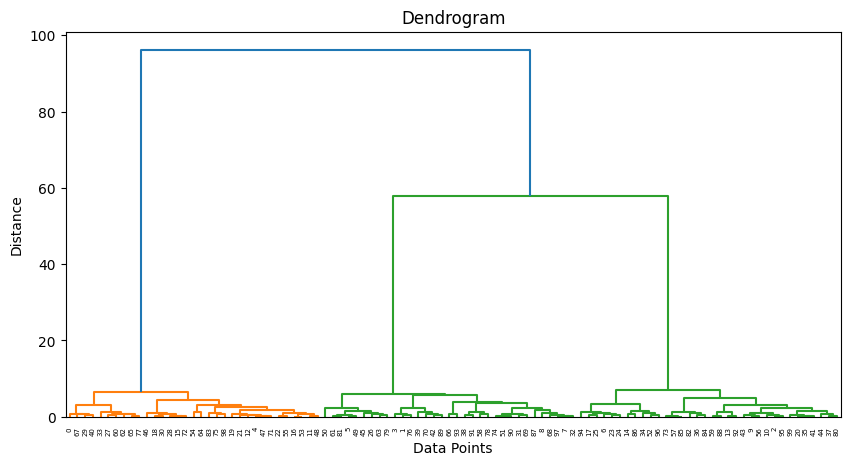

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Compute linkage matrix
Z = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()



---

### **Key Parameters in `AgglomerativeClustering`**

Here’s a breakdown of the most important parameters in `scikit-learn`'s `AgglomerativeClustering`:

#### **1. `n_clusters`**
- **What it does:** Specifies the number of clusters to form as well as the number of centroids to generate.
- **Default:** `2`
- **Use Case:**
  - If you know the desired number of clusters beforehand, set this parameter explicitly.
  - If not specified, you can use a dendrogram or other methods to determine the number of clusters later.

---

#### **2. `affinity` (Deprecated in newer versions; replaced by `metric`)**
- **What it does:** Defines the distance metric used to compute the linkage between data points.
- **Options:**
  - `"euclidean"`: Default, measures straight-line distance.
  - `"manhattan"`: Measures sum of absolute differences.
  - `"cosine"`: Measures cosine similarity.
  - `"l1"`, `"l2"`: Equivalent to Manhattan and Euclidean distances, respectively.
- **Use Case:**
  - Choose based on the nature of your data:
    - Use `"euclidean"` for general-purpose clustering.
    - Use `"cosine"` for text or high-dimensional data.
    - Use `"manhattan"` for grid-like data.

---

#### **3. `linkage`**
- **What it does:** Specifies the linkage criterion to use when merging clusters.
- **Options:**
  - `"ward"`: Minimizes the variance of clusters being merged (only works with `"euclidean"` affinity/metric).
  - `"complete"`: Uses the maximum distance between clusters.
  - `"average"`: Uses the average distance between clusters.
  - `"single"`: Uses the minimum distance between clusters.
- **Default:** `"ward"`
- **Use Case:**
  - `"ward"`: Produces spherical clusters and is computationally efficient.
  - `"complete"`: Useful when clusters are compact and well-separated.
  - `"average"`: Balances sensitivity to outliers and compactness.
  - `"single"`: Captures elongated clusters but is sensitive to noise.

---

#### **4. `distance_threshold`**
- **What it does:** Sets a threshold for the maximum distance between clusters. Clusters will stop merging if the distance exceeds this threshold.
- **Default:** `None`
- **Use Case:**
  - Useful when you want to automatically determine the number of clusters based on a distance cutoff.
  - For example, if you set `distance_threshold=5`, clusters will only merge if their distance is less than or equal to 5.

---

#### **5. `compute_full_tree`**
- **What it does:** Determines whether the full tree of merges should be computed.
- **Options:**
  - `"auto"`: Automatically decides whether to compute the full tree based on `n_clusters` and `distance_threshold`.
  - `True`: Forces computation of the full tree.
  - `False`: Stops computation once the desired number of clusters is reached.
- **Default:** `"auto"`
- **Use Case:**
  - Set to `True` if you want to visualize the full dendrogram.
  - Set to `False` for faster computation when you only care about the final clustering.

---

#### **6. `compute_distances`**
- **What it does:** Whether to compute distances between clusters even if `distance_threshold` is not used.
- **Default:** `False`
- **Use Case:**
  - Set to `True` if you want to inspect inter-cluster distances after clustering (e.g., for visualization).

---

#### **7. `connectivity`**
- **What it does:** Specifies a connectivity matrix that restricts the merging of clusters to neighbors defined by the matrix.
- **Default:** `None`
- **Use Case:**
  - Useful for enforcing spatial constraints (e.g., clustering pixels in an image where only neighboring pixels can belong to the same cluster).
  - For example, you can use a sparse matrix or a precomputed adjacency matrix.

---

#### **8. `memory`**
- **What it does:** Enables caching of the output of expensive computations (e.g., pairwise distances) to improve performance.
- **Default:** `None`
- **Use Case:**
  - Useful for large datasets where recomputing distances repeatedly would be inefficient.

---

### **Example Usage in `scikit-learn`**

Here’s an example of how to use `AgglomerativeClustering` with different parameters:

```python
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic data
X, _ = make_blobs(n_samples=100, centers=3, cluster_std=1.0, random_state=42)

# Perform hierarchical clustering
model = AgglomerativeClustering(
    n_clusters=3,           # Number of clusters
    affinity="euclidean",   # Distance metric
    linkage="ward"          # Linkage criterion
)

# Fit the model and predict clusters
clusters = model.fit_predict(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='rainbow')
plt.title("Hierarchical Clustering Results")
plt.show()
```

---

### **How to Choose Parameters**

1. **Distance Metric (`affinity`):**
   - Use `"euclidean"` for general-purpose clustering.
   - Use `"cosine"` for text or high-dimensional data.
   - Use `"manhattan"` for grid-like data.

2. **Linkage Criterion (`linkage`):**
   - Use `"ward"` for spherical clusters and efficient computation.
   - Use `"complete"` for compact clusters.
   - Use `"average"` for balanced clustering.
   - Use `"single"` for elongated clusters (but beware of noise).

3. **Number of Clusters (`n_clusters`):**
   - Specify if you know the desired number of clusters.
   - Use a dendrogram to decide otherwise.

4. **Distance Threshold (`distance_threshold`):**
   - Use when you want automatic determination of clusters based on a distance cutoff.

5. **Connectivity (`connectivity`):**
   - Use when you need spatial constraints (e.g., image segmentation).

---

### **Visualizing the Dendrogram**

To visualize the hierarchy of clusters, you can use `scipy`’s `dendrogram` function:

```python
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Compute linkage matrix
Z = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()
```

---

### **Summary Table: Parameter Use Cases**

| **Parameter**         | **Purpose**                                                   | **Common Values**                         |
|------------------------|---------------------------------------------------------------|-------------------------------------------|
| `n_clusters`           | Number of clusters to form                                    | Integer (e.g., `3`, `5`)                  |
| `affinity` (or `metric`)| Distance metric                                              | `"euclidean"`, `"manhattan"`, `"cosine"` |
| `linkage`              | Linkage criterion for merging clusters                        | `"ward"`, `"complete"`, `"average"`      |
| `distance_threshold`   | Maximum distance for merging clusters                         | Float (e.g., `1.5`, `5.0`)               |
| `compute_full_tree`    | Whether to compute the full dendrogram                        | `"auto"`, `True`, `False`                |
| `compute_distances`    | Whether to compute inter-cluster distances                    | `True`, `False`                          |
| `connectivity`         | Spatial constraints for clustering                            | Sparse matrix or adjacency matrix        |
| `memory`               | Cache intermediate computations for efficiency               | Path to cache directory                  |

---

### **Final Notes**
By carefully tuning these parameters, you can adapt hierarchical clustering to a wide variety of problems. Always consider the nature of your data (e.g., dimensionality, noise, spatial constraints) when selecting parameters. If you’re unsure, start with default values and experiment iteratively.

